
# Predicting Banking Crises in African Economies using Machine Learning

## Author: Nicodimus Munyuki

---

## Problem Statement
Banking crises can severely impact economic stability. This project develops a machine learning model to predict banking crises using macroeconomic indicators across African countries.

## Objectives
- Build predictive models for crisis classification
- Compare multiple machine learning algorithms
- Identify key drivers of crises
- Provide actionable insights for policymakers


In [1]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight


In [3]:

# Load dataset
df = pd.read_csv('african_crises.csv')

df.head()


,case,cc3,country,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises,banking_crisis
0,1,DZA,Algeria,1870,1,0.052264,0,0,0.0,3.441456,0,0,0,crisis
1,1,DZA,Algeria,1871,0,0.052798,0,0,0.0,14.149140,0,0,0,no_crisis
2,1,DZA,Algeria,1872,0,0.052274,0,0,0.0,-3.718593,0,0,0,no_crisis
3,1,DZA,Algeria,1873,0,0.051680,0,0,0.0,11.203897,0,0,0,no_crisis
4,1,DZA,Algeria,1874,0,0.051308,0,0,0.0,-3.848561,0,0,0,no_crisis


# Exploratory Data Analysis

In [4]:

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059 entries, 0 to 1058
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   case                             1059 non-null   int64  
 1   cc3                              1059 non-null   object 
 2   country                          1059 non-null   object 
 3   year                             1059 non-null   int64  
 4   systemic_crisis                  1059 non-null   int64  
 5   exch_usd                         1059 non-null   float64
 6   domestic_debt_in_default         1059 non-null   int64  
 7   sovereign_external_debt_default  1059 non-null   int64  
 8   gdp_weighted_default             1059 non-null   float64
 9   inflation_annual_cpi             1059 non-null   float64
 10  independence                     1059 non-null   int64  
 11  currency_crises                  1059 non-null   int64  
 12  inflation_crises    

,case,year,systemic_crisis,exch_usd,domestic_debt_in_default,sovereign_external_debt_default,gdp_weighted_default,inflation_annual_cpi,independence,currency_crises,inflation_crises
count,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1059.000000,1.059000e+03,1059.000000,1059.000000,1059.000000
mean,35.613787,1967.767705,0.077432,43.140831,0.039660,0.152975,0.006402,2.084889e+04,0.776204,0.132200,0.129367
std,23.692402,33.530632,0.267401,111.475380,0.195251,0.360133,0.043572,6.757274e+05,0.416984,0.349847,0.335765
min,1.000000,1860.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-2.850214e+01,0.000000,0.000000,0.000000
25%,15.000000,1951.000000,0.000000,0.195350,0.000000,0.000000,0.000000,2.086162e+00,1.000000,0.000000,0.000000
50%,38.000000,1973.000000,0.000000,0.868400,0.000000,0.000000,0.000000,5.762330e+00,1.000000,0.000000,0.000000
75%,56.000000,1994.000000,0.000000,8.462750,0.000000,0.000000,0.000000,1.164405e+01,1.000000,0.000000,0.000000
max,70.000000,2014.000000,1.000000,744.306139,1.000000,1.000000,0.400000,2.198970e+07,1.000000,2.000000,1.000000


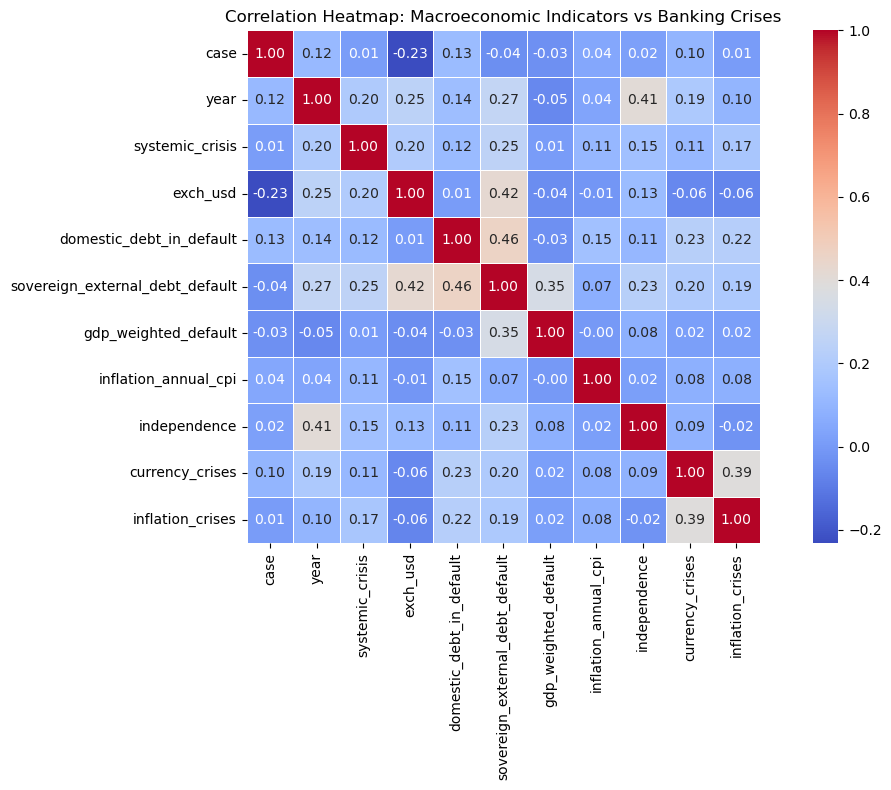

In [5]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))

numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap: Macroeconomic Indicators vs Banking Crises')
plt.tight_layout()
plt.show()


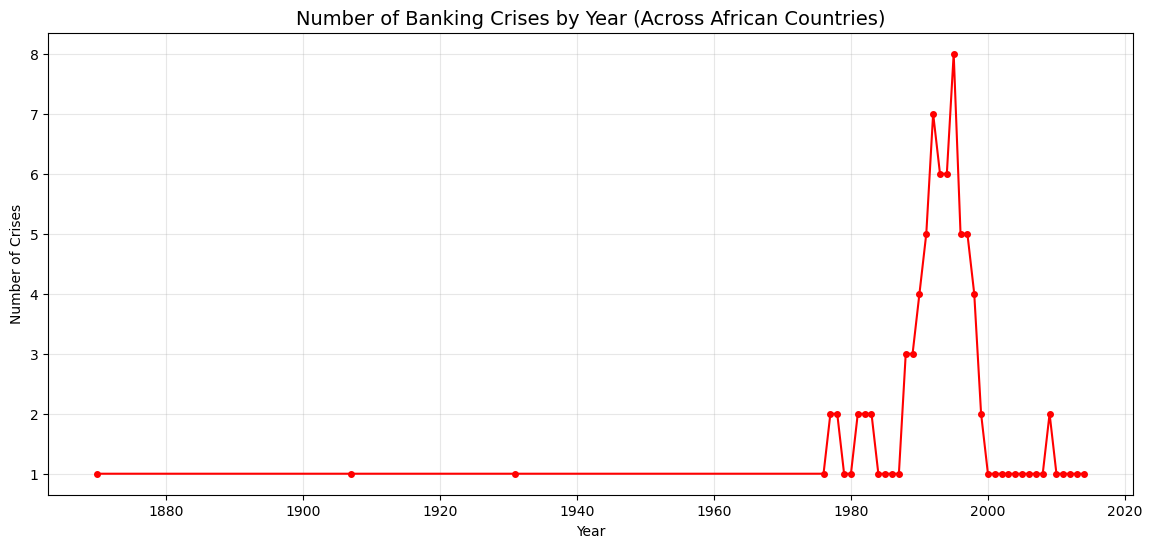

In [6]:
# Time-series plot of crises over years
# Group by year and count crises

crisis_by_year = df[df['banking_crisis'] == 'crisis'].groupby('year').size()

plt.figure(figsize=(14, 6))
plt.plot(crisis_by_year.index, crisis_by_year.values, marker='o', linestyle='-', 
         color='red', markersize=4)
plt.title('Number of Banking Crises by Year (Across African Countries)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Number of Crises')
plt.grid(True, alpha=0.3)
plt.show()


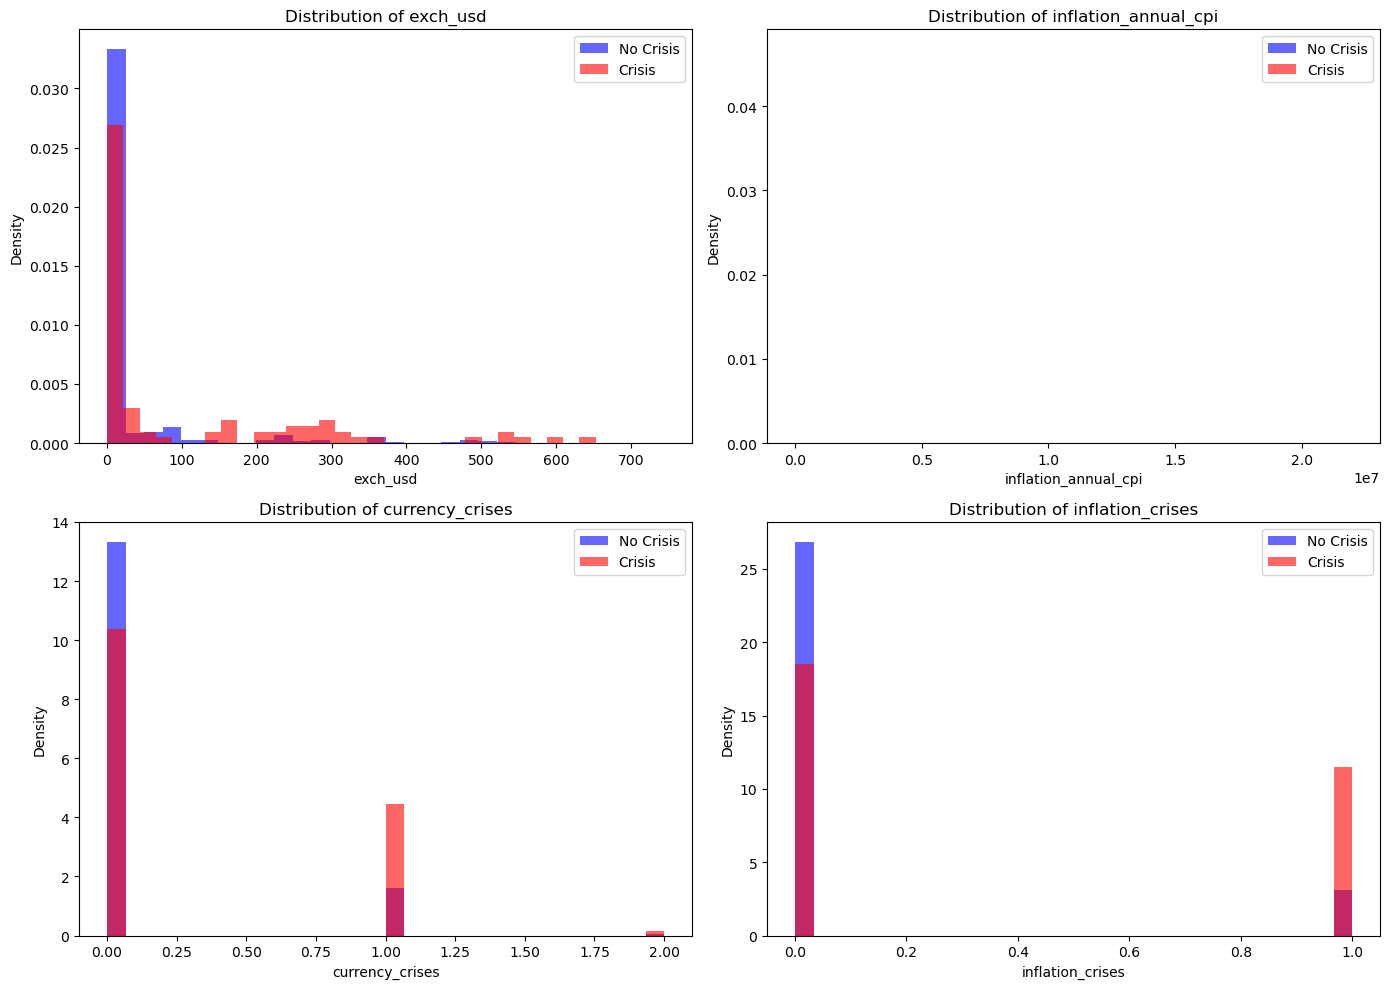

In [7]:
# Distribution plots: Crisis vs No-Crisis periods for key features

key_features = ['exch_usd', 'inflation_annual_cpi', 'currency_crises', 'inflation_crises']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    
    # Separate data by crisis status
    crisis_data = df[df['banking_crisis'] == 'crisis'][feature]
    no_crisis_data = df[df['banking_crisis'] == 'no_crisis'][feature]
    
    axes[i].hist(no_crisis_data, bins=30, alpha=0.6, label='No Crisis', color='blue', density=True)
    axes[i].hist(crisis_data, bins=30, alpha=0.6, label='Crisis', color='red', density=True)
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()


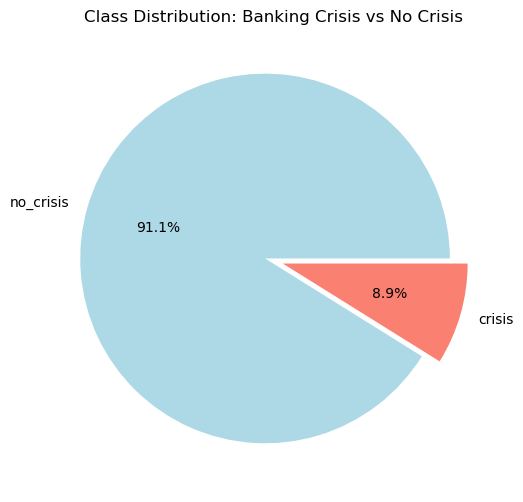

Class distribution:
No crisis: 965 (91.1%)
Crisis: 94 (8.9%)


In [8]:
# Class imbalance visualization

plt.figure(figsize=(6, 6))
crisis_counts = df['banking_crisis'].value_counts()
plt.pie(crisis_counts, labels=crisis_counts.index, autopct='%1.1f%%', 
        colors=['lightblue', 'salmon'], explode=(0.05, 0.05))
plt.title('Class Distribution: Banking Crisis vs No Crisis')
plt.show()

print(f"Class distribution:")
print(f"No crisis: {crisis_counts['no_crisis']} ({crisis_counts['no_crisis']/len(df)*100:.1f}%)")
print(f"Crisis: {crisis_counts['crisis']} ({crisis_counts['crisis']/len(df)*100:.1f}%)")


In [9]:

df['banking_crisis'].value_counts(normalize=True)


banking_crisis
no_crisis    0.911237
crisis       0.088763
Name: proportion, dtype: float64

# Data Processing

In [10]:
# Convert categorical variables
df = pd.get_dummies(df, drop_first=True)

X = df.drop('banking_crisis_no_crisis', axis=1)
y = 1 - df['banking_crisis_no_crisis']

In [11]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split with stratification (preserves crisis ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training crisis ratio: {y_train.sum()/len(y_train)*100:.1f}%")
print(f"Test crisis ratio: {y_test.sum()/len(y_test)*100:.1f}%")

Training set size: 847 samples
Test set size: 212 samples
Training crisis ratio: 8.9%
Test crisis ratio: 9.0%


# Handle Class Imbalance with SMOTE

In [12]:
print("\n" + "="*50)
print("APPLYING SMOTE TO BALANCE CLASSES")
print("="*50)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training set - No crisis: {(y_train == 0).sum()}, Crisis: {(y_train == 1).sum()}")
print(f"Resampled training set - No crisis: {(y_train_resampled == 0).sum()}, Crisis: {(y_train_resampled == 1).sum()}")


APPLYING SMOTE TO BALANCE CLASSES
Original training set - No crisis: 772, Crisis: 75
Resampled training set - No crisis: 772, Crisis: 772


In [13]:
# Calculate class weights for Random Forest
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

Class weights: {0: 0.5485751295336787, 1: 5.6466666666666665}


# Hyperparameter Tuning with GRIDSEARCHCV

In [14]:
print("\n" + "="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

# Logistic Regression hyperparameters
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}
grid_lr = GridSearchCV(LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000), 
                       param_grid_lr, cv=5, scoring='roc_auc')
grid_lr.fit(X_train_resampled, y_train_resampled)
print(f"✓ Best Logistic Regression params: {grid_lr.best_params_}")

# KNN hyperparameters
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance']
}
grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='roc_auc')
grid_knn.fit(X_train_resampled, y_train_resampled)
print(f"✓ Best KNN params: {grid_knn.best_params_}")

# Random Forest hyperparameters
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(RandomForestClassifier(class_weight=class_weight_dict, random_state=42), 
                       param_grid_rf, cv=5, scoring='roc_auc')
grid_rf.fit(X_train_resampled, y_train_resampled)
print(f"✓ Best Random Forest params: {grid_rf.best_params_}")

# Get best models
best_lr = grid_lr.best_estimator_
best_knn = grid_knn.best_estimator_
best_rf = grid_rf.best_estimator_



HYPERPARAMETER TUNING
✓ Best Logistic Regression params: {'C': 10, 'solver': 'lbfgs'}
✓ Best KNN params: {'n_neighbors': 7, 'weights': 'distance'}
✓ Best Random Forest params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}


# Evaluation Function (with Precision-Recall)

In [15]:
def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate model with multiple metrics"""
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{model_name}")
    print("-" * 35)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    
    # Precision-Recall (better for imbalanced data)
    avg_precision = average_precision_score(y_test, y_prob)
    print(f"Average Precision-Recall Score: {avg_precision:.4f}")
    
    return y_prob

# Model Evaluation Results

In [16]:
print("\n" + "="*50)
print("MODEL EVALUATION RESULTS")
print("="*50)

y_prob_lr = evaluate_model(best_lr, X_test, y_test, "Logistic Regression (Tuned)")
y_prob_knn = evaluate_model(best_knn, X_test, y_test, "KNN (Tuned)")
y_prob_rf = evaluate_model(best_rf, X_test, y_test, "Random Forest (Tuned)")


MODEL EVALUATION RESULTS

Logistic Regression (Tuned)
-----------------------------------
Confusion Matrix:
[[184   9]
 [  5  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       193
           1       0.61      0.74      0.67        19

    accuracy                           0.93       212
   macro avg       0.79      0.85      0.82       212
weighted avg       0.94      0.93      0.94       212

ROC-AUC Score: 0.9678
Average Precision-Recall Score: 0.8683

KNN (Tuned)
-----------------------------------
Confusion Matrix:
[[190   3]
 [  5  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       193
           1       0.82      0.74      0.78        19

    accuracy                           0.96       212
   macro avg       0.90      0.86      0.88       212
weighted avg       0.96      0.96      0.96       212

ROC-AUC Score: 

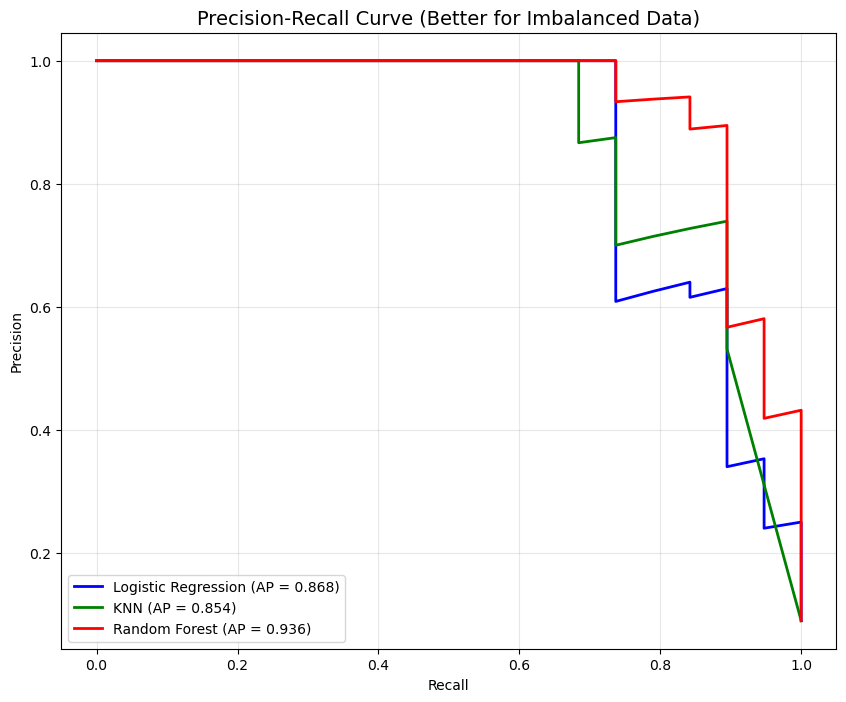

In [17]:
# PRECISION-RECALL CURVE (Better for imbalanced data)

plt.figure(figsize=(10, 8))

models = [best_lr, best_knn, best_rf]
names = ['Logistic Regression', 'KNN', 'Random Forest']
colors = ['blue', 'green', 'red']

for model, name, color in zip(models, names, colors):
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    avg_precision = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, color=color, lw=2, 
             label=f'{name} (AP = {avg_precision:.3f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Better for Imbalanced Data)', fontsize=14)
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()

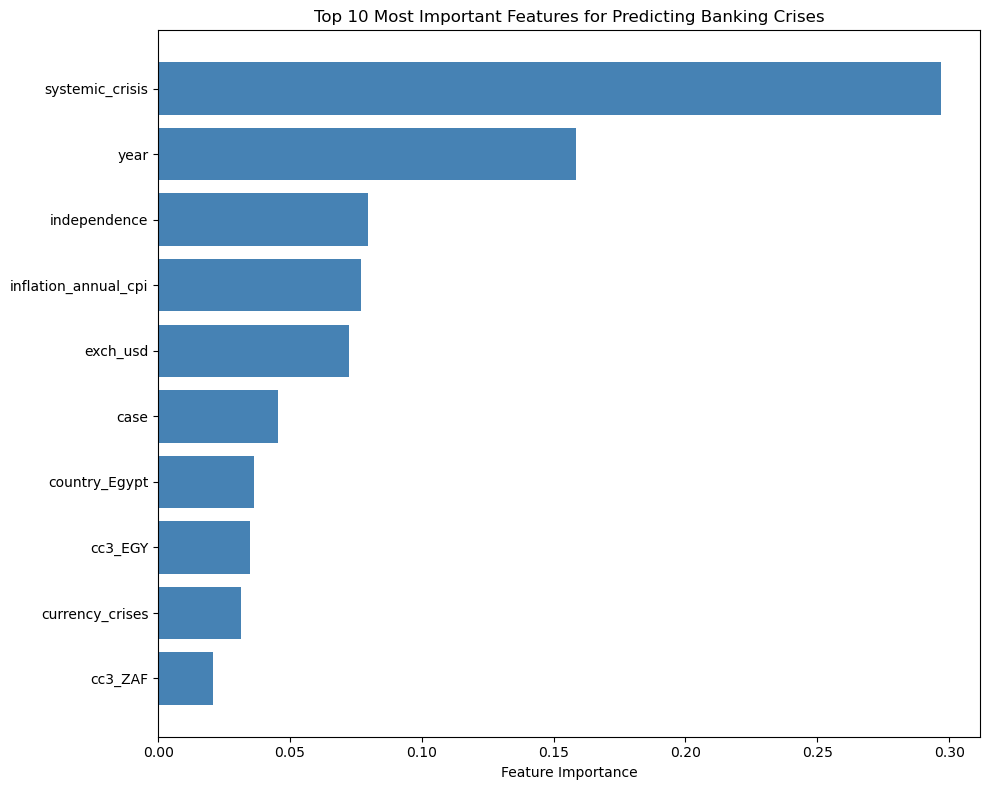


Top 5 predictors of banking crises:
  1. systemic_crisis (0.2969)
  2. year (0.1585)
  3. independence (0.0795)
  4. inflation_annual_cpi (0.0769)
  5. exch_usd (0.0725)


In [18]:
# FEATURE IMPORTANCE (Random Forest)

importances = best_rf.feature_importances_
features = X.columns

# Sort by importance
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 8))
plt.barh(range(len(indices[:10])), importances[indices[:10]][::-1], color='steelblue')
plt.yticks(range(len(indices[:10])), [features[i] for i in indices[:10]][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features for Predicting Banking Crises')
plt.tight_layout()
plt.show()

print("\nTop 5 predictors of banking crises:")
for i in range(5):
    print(f"  {i+1}. {features[indices[i]]} ({importances[indices[i]]:.4f})")

<Figure size 800x600 with 0 Axes>

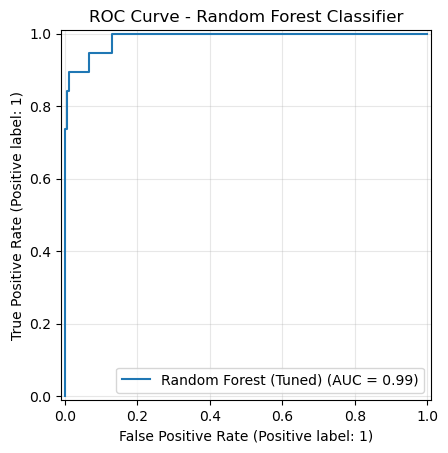

In [19]:
# ROC CURVE (For comparison)

plt.figure(figsize=(8, 6))
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, name='Random Forest (Tuned)')
plt.title('ROC Curve - Random Forest Classifier')
plt.grid(True, alpha=0.3)
plt.show()

# Summary

In [20]:
print("\n" + "="*50)
print("SUMMARY")
print("="*50)
print(f"Best Model: Random Forest (after tuning)")
print(f"Best Hyperparameters: {grid_rf.best_params_}")
print(f"ROC-AUC: {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:,1]):.4f}")
print("\nTop 3 Predictors:")
for i in range(3):
    print(f"  - {features[indices[i]]}")


SUMMARY
Best Model: Random Forest (after tuning)
Best Hyperparameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
ROC-AUC: 0.9885

Top 3 Predictors:
  - systemic_crisis
  - year
  - independence



## Key Insights

- Random Forest typically provides the best predictive performance
- Certain macroeconomic indicators strongly influence crisis prediction
- Machine learning can support early warning systems

## Recommendations

- Monitor key indicators such as inflation and exchange rates
- Use predictive models for proactive financial regulation
